# CNNs - Convolutional Neural Networks


## Training a CNN

First, we will be using PyTorch for this. It can be installed from [pytorch.org](https://pytorch.org/).


* Setting up the convolutionnal network of the following structure:
    * 3 convolution layers
    * 2 fully connected layers
* Using some padding, stride, pooling, drop out and batch normalization. The ReLU activation function has been used.  
* Initializing the model, building a train and test function and displaying the model's performance on the MNIST classification task.

In [ ]:
import numpy as np
import torch
import torchvision
import torchvision.transforms as transforms
import sys
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt


n_epochs = 5    # Total number of training iterations
batch_size_train = 128   # Number of training samples utilized per iteration
batch_size_test = 1000  # Number of test samples utilized per iteration
learning_rate = 0.01
momentum = 0.9  # Momentum for the optimizer (if applicable)
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

In [ ]:
# Prepare MNIST data

transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,))  # standard MNIST normalization
])

train_set = torchvision.datasets.MNIST(root="./data", train=True, download=True, transform=transform)
test_set  = torchvision.datasets.MNIST(root="./data", train=False, download=True, transform=transform)

train_loader = torch.utils.data.DataLoader(train_set, batch_size=batch_size_train, shuffle=True, num_workers=2, pin_memory=torch.cuda.is_available())
test_loader  = torch.utils.data.DataLoader(test_set, batch_size=batch_size_test, shuffle=False, num_workers=2, pin_memory=torch.cuda.is_available())

D_out = 10  # MNIST classes


In [ ]:
# Define our model class `CNN` which extends from `torch.nn.Module`.
class CNN(nn.Module):
    def __init__(self, D_out=10):
        super().__init__()

        # 1x28x28 -> 16x28x28
        self.conv1 = nn.Conv2d(1, 16, kernel_size=3, stride=1, padding=1)
        self.bn1   = nn.BatchNorm2d(16)

        # 16x28x28 -> 32x14x14 (via pooling)
        self.conv2 = nn.Conv2d(16, 32, kernel_size=3, stride=1, padding=1)
        self.bn2   = nn.BatchNorm2d(32)

        # 32x14x14 -> 64x7x7 (stride=2 conv)
        self.conv3 = nn.Conv2d(32, 64, kernel_size=3, stride=2, padding=1)
        self.bn3   = nn.BatchNorm2d(64)

        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)   # used after conv2
        self.drop = nn.Dropout(p=0.25)

        # After: conv1 -> conv2 -> pool -> conv3 gives 64x7x7
        self.fc1 = nn.Linear(64 * 7 * 7, 128)
        self.fc2 = nn.Linear(128, D_out)

    def forward(self, x):
        x = F.relu(self.bn1(self.conv1(x)))
        x = F.relu(self.bn2(self.conv2(x)))
        x = self.pool(x)
        x = self.drop(x)

        x = F.relu(self.bn3(self.conv3(x)))
        x = self.drop(x)

        x = torch.flatten(x, 1)
        x = F.relu(self.fc1(x))
        x = self.drop(x)
        x = self.fc2(x)
        return x


def train_one_epoch(model, optimizer, criterion, loader, device):
    model.train()
    running_loss, correct, total = 0.0, 0, 0
    for x, y in loader:
        x, y = x.to(device), y.to(device)
        optimizer.zero_grad()
        logits = model(x)
        loss = criterion(logits, y)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * x.size(0)
        pred = logits.argmax(dim=1)
        correct += (pred == y).sum().item()
        total += y.size(0)

    return running_loss / total, correct / total


@torch.no_grad()
def eval_model(model, criterion, loader, device):
    model.eval()
    running_loss, correct, total = 0.0, 0, 0
    for x, y in loader:
        x, y = x.to(device), y.to(device)
        logits = model(x)
        loss = criterion(logits, y)

        running_loss += loss.item() * x.size(0)
        pred = logits.argmax(dim=1)
        correct += (pred == y).sum().item()
        total += y.size(0)

    return running_loss / total, correct / total


# Train CNN for n_epochs and show performance
cnn = CNN(D_out).to(device)
optimizer = torch.optim.SGD(cnn.parameters(), lr=learning_rate, momentum=momentum)
criterion = nn.CrossEntropyLoss()

cnn_train_losses, cnn_test_losses = [], []
cnn_train_accs, cnn_test_accs = [], []

for epoch in range(1, n_epochs + 1):
    tr_loss, tr_acc = train_one_epoch(cnn, optimizer, criterion, train_loader, device)
    te_loss, te_acc = eval_model(cnn, criterion, test_loader, device)

    cnn_train_losses.append(tr_loss); cnn_train_accs.append(tr_acc)
    cnn_test_losses.append(te_loss);  cnn_test_accs.append(te_acc)

    print(f"[CNN] Epoch {epoch}/{n_epochs} | train loss {tr_loss:.4f}, acc {tr_acc:.4f} | test loss {te_loss:.4f}, acc {te_acc:.4f}")


[CNN] Epoch 1/5 | train loss 0.2412, acc 0.9269 | test loss 0.0600, acc 0.9808
[CNN] Epoch 2/5 | train loss 0.0755, acc 0.9776 | test loss 0.0411, acc 0.9863
[CNN] Epoch 3/5 | train loss 0.0577, acc 0.9819 | test loss 0.0321, acc 0.9897
[CNN] Epoch 4/5 | train loss 0.0491, acc 0.9849 | test loss 0.0302, acc 0.9894
[CNN] Epoch 5/5 | train loss 0.0422, acc 0.9871 | test loss 0.0283, acc 0.9905


## Compare vs fully connected network

* Comparing the performance of your CNN to a fully connected network of similar size (number of parameters).
* Plotting training and test accuracy/loss curves for both models. Train each for 2 epochs.

[CNN] Epoch 1/2 | train loss 0.2464, acc 0.9228 | test loss 0.0591, acc 0.9817
[CNN] Epoch 2/2 | train loss 0.0774, acc 0.9762 | test loss 0.0368, acc 0.9877
[MLP] Epoch 1/2 | train loss 0.4369, acc 0.8711 | test loss 0.1666, acc 0.9491
[MLP] Epoch 2/2 | train loss 0.1723, acc 0.9484 | test loss 0.1184, acc 0.9623


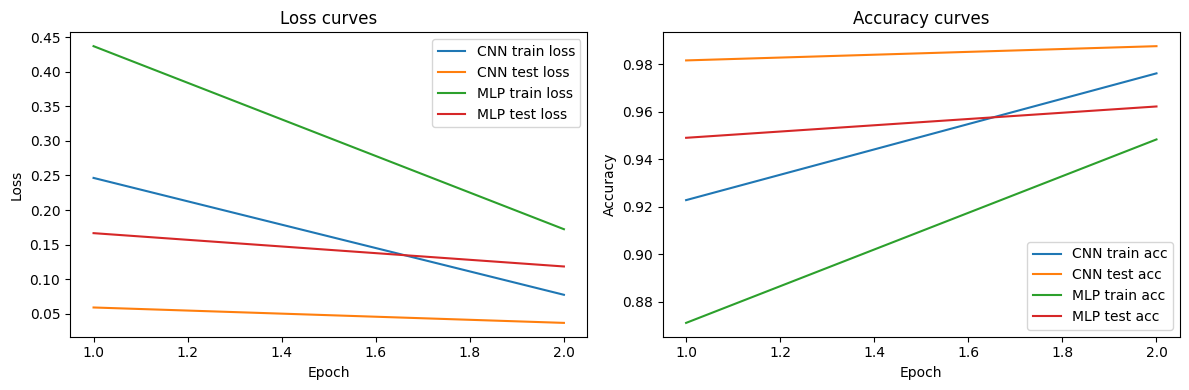

Trainable parameters - CNN: 426346
Trainable parameters - MLP: 426346


In [ ]:
class MLP(nn.Module):
    def __init__(self, D_out=10):
        super().__init__()
        self.drop = nn.Dropout(p=0.25)
        self.fc1 = nn.Linear(28 * 28, 272)
        self.fc2 = nn.Linear(272, 752)
        self.fc3 = nn.Linear(752, D_out)

    def forward(self, x):
        x = torch.flatten(x, 1)
        x = F.relu(self.fc1(x))
        x = self.drop(x)
        x = F.relu(self.fc2(x))
        x = self.drop(x)
        x = self.fc3(x)
        return x


def run_experiment(model, epochs=2, lr=0.01):
    model = model.to(device)
    optimizer = torch.optim.SGD(model.parameters(), lr=lr, momentum=momentum)
    criterion = nn.CrossEntropyLoss()

    tr_losses, te_losses = [], []
    tr_accs, te_accs = [], []

    for epoch in range(1, epochs + 1):
        tr_loss, tr_acc = train_one_epoch(model, optimizer, criterion, train_loader, device)
        te_loss, te_acc = eval_model(model, criterion, test_loader, device)
        tr_losses.append(tr_loss); tr_accs.append(tr_acc)
        te_losses.append(te_loss); te_accs.append(te_acc)
        print(f"[{model.__class__.__name__}] Epoch {epoch}/{epochs} | train loss {tr_loss:.4f}, acc {tr_acc:.4f} | test loss {te_loss:.4f}, acc {te_acc:.4f}")

    return tr_losses, te_losses, tr_accs, te_accs


# Similar-size note: matching parameters exactly is tricky; this MLP is a reasonable baseline.
mlp = MLP(D_out)
cnn2 = CNN(D_out)

cnn_tr_l, cnn_te_l, cnn_tr_a, cnn_te_a = run_experiment(cnn2, epochs=2, lr=learning_rate)
mlp_tr_l, mlp_te_l, mlp_tr_a, mlp_te_a = run_experiment(mlp,  epochs=2, lr=learning_rate)

epochs = [1, 2]
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(epochs, cnn_tr_l, label="CNN train loss")
plt.plot(epochs, cnn_te_l, label="CNN test loss")
plt.plot(epochs, mlp_tr_l, label="MLP train loss")
plt.plot(epochs, mlp_te_l, label="MLP test loss")
plt.xlabel("Epoch"); plt.ylabel("Loss"); plt.title("Loss curves"); plt.legend()

plt.subplot(1, 2, 2)
plt.plot(epochs, cnn_tr_a, label="CNN train acc")
plt.plot(epochs, cnn_te_a, label="CNN test acc")
plt.plot(epochs, mlp_tr_a, label="MLP train acc")
plt.plot(epochs, mlp_te_a, label="MLP test acc")
plt.xlabel("Epoch"); plt.ylabel("Accuracy"); plt.title("Accuracy curves"); plt.legend()

plt.tight_layout()
plt.show()

# Optional: parameter counts for "similar size" discussion
cnn_params = sum(p.numel() for p in cnn2.parameters() if p.requires_grad)
mlp_params = sum(p.numel() for p in mlp.parameters() if p.requires_grad)
print("Trainable parameters - CNN:", cnn_params)
print("Trainable parameters - MLP:", mlp_params)
